<a href="https://colab.research.google.com/github/2023AC05202/pytorch_tutorial_1/blob/develop/5_Simple_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [105]:
# Create a model class that inherits the nn.Module
class Model(nn.Module):
    # Input layer (4 feature of the input)
    # Hidden layer 1 (number of neurons)
    # Hidden layer 2 (number of neurons)
    # Output layer (3 classes of flower)
    # Define the constructor
    def __init__(self, in_feature = 4, h1 = 8, h2 = 8, output_feature = 3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_feature, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, output_feature)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [106]:
#pick a manual seed for randomization
torch.manual_seed(20)
model = Model()

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [108]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'

df = pd.read_csv(url)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [109]:
df['species'] = df['species'].replace({'setosa':0, 'versicolor':1, 'virginica':2})
df

<ipython-input-109-76fede25ca5d>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species'] = df['species'].replace({'setosa':0, 'versicolor':1, 'virginica':2})


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [110]:
#Train and test split
X = df.drop('species', axis = 1).values
y = df['species'].values

In [111]:
from sklearn.model_selection import train_test_split

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 41)

In [113]:
#Convert the x feature to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [114]:
# Convert the y labels to long tensors
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [115]:
#Set the criterian of the model to measure the error, how far off the predictions are from the data
criterian = nn.CrossEntropyLoss()
# choose the ADAM optimiser, lr = learning rate (if error does not go down after a bunch of iterations(epochs), lower our learning rate)
optimiser = torch.optim.Adam(model.parameters(), lr = 0.01)


In [116]:
# Train our model
#Epoch : one run through all data
epochs = 100
losses = []

for i in range(epochs):

  # Feed forwward and get predictions
  y_pred = model.forward(X_train)

  # Calculate the losses/error (y_prediction vs y_train)
  loss = criterian(y_pred, y_train)

  #Keep track of our losses
  losses.append(loss.detach().numpy())

  #print every 10 epochs
  if i%10 == 0:
    print(f'Epoch: {i} and loss: {loss}')


  # Back propogation : take the error rate of forward propagation and feed it
  # back to network to fine tune the weight
  optimiser.zero_grad()
  loss.backward()
  optimiser.step()

Epoch: 0 and loss: 1.065075397491455
Epoch: 10 and loss: 0.7831348180770874
Epoch: 20 and loss: 0.5588374733924866
Epoch: 30 and loss: 0.40698400139808655
Epoch: 40 and loss: 0.2890453636646271
Epoch: 50 and loss: 0.17541562020778656
Epoch: 60 and loss: 0.09981182217597961
Epoch: 70 and loss: 0.06357786804437637
Epoch: 80 and loss: 0.04671319201588631
Epoch: 90 and loss: 0.037880703806877136


Text(0.5, 0, 'Epoch')

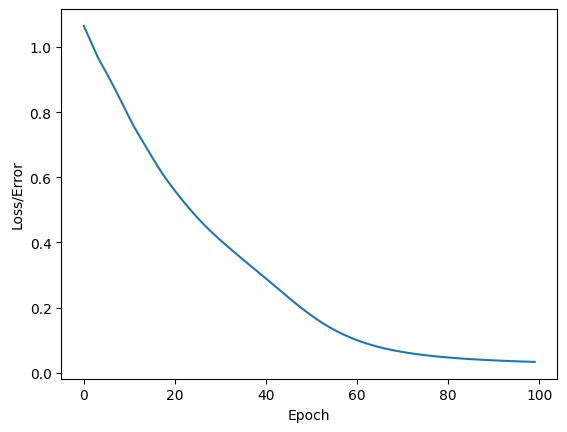

In [117]:
#Graph it out
plt.plot(range(epochs), losses)
plt.ylabel('Loss/Error')
plt.xlabel('Epoch')

In [120]:
#Evaluate model with test data set( validate  model on test data)
with torch.no_grad(): # Turn off the back propagation

  # X_test are feature from our test set
  y_eval = model.forward(X_test)

  # calculate the loss
  loss = criterian(y_eval, y_test)

print(f'The loss/error is: {loss}')

The loss/error is: 0.13365741074085236


In [124]:
# check how many of test data prediction are correct
correct = 0

with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    print(f'{i+1:2}. {str(data.numpy()):28} {y_test[i]:5} {y_val.argmax().item():<4}')

    # correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'\n{correct} out of {len(y_test)} = {100*correct/len(y_test):.2f}% correct')


 1. [6.  2.2 5.  1.5]                2 2   
 2. [6.4 2.8 5.6 2.1]                2 2   
 3. [7.7 3.  6.1 2.3]                2 2   
 4. [6.1 3.  4.6 1.4]                1 1   
 5. [6.8 3.  5.5 2.1]                2 2   
 6. [6.1 2.8 4.  1.3]                1 1   
 7. [6.3 2.7 4.9 1.8]                2 2   
 8. [6.  3.4 4.5 1.6]                1 1   
 9. [6.5 3.  5.2 2. ]                2 2   
10. [6.8 3.2 5.9 2.3]                2 2   
11. [6.1 3.  4.9 1.8]                2 2   
12. [5.1 3.4 1.5 0.2]                0 0   
13. [4.4 3.  1.3 0.2]                0 0   
14. [5.  2.3 3.3 1. ]                1 1   
15. [5.1 3.3 1.7 0.5]                0 0   
16. [6.3 2.8 5.1 1.5]                2 1   
17. [4.8 3.1 1.6 0.2]                0 0   
18. [6.  2.7 5.1 1.6]                1 2   
19. [4.9 3.1 1.5 0.1]                0 0   
20. [4.5 2.3 1.3 0.3]                0 0   
21. [5.5 2.4 3.7 1. ]                1 1   
22. [6.9 3.2 5.7 2.3]                2 2   
23. [5.  3.5 1.6 0.6]           

In [125]:
#Run network on new data point
data_point = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [129]:
with torch.no_grad():
  print(model(data_point))



tensor([ 15.6533,   9.5061, -17.4223])


In [130]:
# save our NN model
torch.save(model.state_dict(), 'model-iris.pth')

In [131]:
#Load the saved model
new_model = Model()
new_model.load_state_dict(torch.load('model-iris.pth'))

<ipython-input-131-353a576e98bd>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load('model-iris.pth'))


<All keys matched successfully>

In [132]:
# Make sure it loaded successfully
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)